#### ⏰ Deadline: Wednesday, June 17, 20:00
### What is this notebook about? 

You may have heard about the COMPAS controversy, a famous debate in algorithmic fairness. The controversy focused on whether an algorithm that predicts recidivism (reoffending after a previous conviction) treated different racial groups fairly. As you probably have guessed - it did not. 

In this notebook, you will work with a simplified version of the COMPAS dataset and explore this controversy firsthand. Rather than focusing on formal definitions, you will investigate the underlying ideas intuitively. In the tutorial session itself, these insights will be contextualized within the broader landscape of fairness metrics.

🚀 Time to get started! 

---
#### 🟢 Station 1 - Assessing the model performance 

We will start with a simple model predicting recidivism rate from race, sex, age number of prior offenses (priors_count) and charge severity (c_charge_degree, felony vs. misdemeanor). The model is already implemented below to make it easier to get started. 

- Download the **Compass data** from the Jupyter Book under Data for Chapter 3
- Once you have the data, run the next code cells to get started!
- If you encounter any dependency errors, adjust the code (with the help of an LLM)!

📌 Note that the code has been generated with the help of an LLM but it has been inspected for the purposes of this exercise. Additional comments have been added to aid your unterstanding! 


In [1]:
# Load the cleaned COMPAS dataset by specifying the path to the file 
# df = pd.read_csv("FILEPATH")
import pandas as pd
df = pd.read_csv("compas_clean.csv")


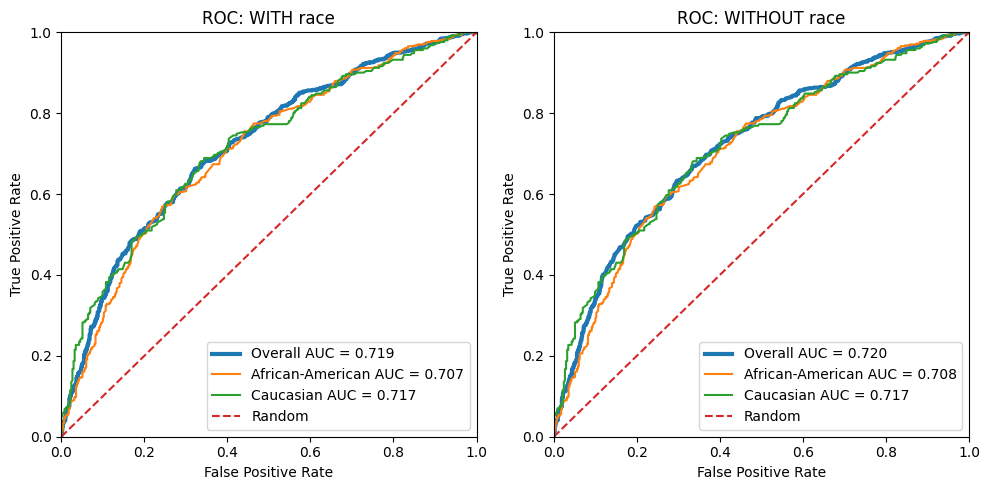

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Keep only the two racial groups discussed in the COMPAS controversy
df = df[df["race"].isin(["African-American", "Caucasian"])].copy()

# Target: 1 = reoffended within two years
y = df["two_year_recid"].astype(int)

# Protected attribute used later for fairness analysis
race = df["race"]

# the train/test split is random
train_idx, test_idx = train_test_split(df.index,test_size=0.25,random_state=42, stratify=y)
base_features = ["sex", "age", "priors_count", "c_charge_degree"]

# Compare a model that can use race with one that cannot
model_specs = {"WITH race": base_features + ["race"],
    "WITHOUT race": base_features}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
trained_models = {}

for ax, (title, features) in zip(axes, model_specs.items()):
    X = df[features]

    # Separate categorical and numerical features
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    num_cols = [c for c in features if c not in cat_cols]

    model = Pipeline(
        [("prep", ColumnTransformer(
        [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)])),
        ("clf", LogisticRegression(max_iter=1000))] 
    )

    # Train model
    model.fit(X.loc[train_idx], y.loc[train_idx])

    # True outcomes and race information for the test set
    # (used later to evaluate fairness across groups)
    
    y_test = y.loc[test_idx]
    race_test = race.loc[test_idx]

    # Predicted probability of recidivism
    y_score = model.predict_proba(X.loc[test_idx])[:, 1]

    # Convert probabilities into binary predictions
    y_pred = (y_score >= 0.5).astype(int)

    trained_models[title] = {
        "model": model,
        "features": features,
        "y_test": y_test,
        "race_test": race_test,
        "y_score": y_score,
        "y_pred": y_pred,}

    # Overall ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    ax.plot(fpr, tpr, linewidth=3, label=f"Overall AUC = {auc(fpr, tpr):.3f}")

    # ROC curves for each racial group
    for group in sorted(race_test.unique()):
        mask = race_test == group
        fpr_g, tpr_g, _ = roc_curve(y_test[mask], y_score[mask])
        ax.plot(fpr_g, tpr_g, label=f"{group} AUC = {auc(fpr_g, tpr_g):.3f}")

    # Random guessing baseline
    ax.plot([0, 1], [0, 1], "--", label="Random")

    ax.set_title(f"ROC: {title}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

# Keep the model without race for the fairness audit below
audit = trained_models["WITHOUT race"]


### 💡 Station 1 - Reflection
- Based on the results so far, what do you conclude regarding model fairness?
- Do you have enough information as of now? 
- What further information would you like to know, if any?

---
#### 🟢🟢 Station 2 - Fairness audit

There are many competing definitions and metrics of fairness. While they emphasize different notions of what it means to be fair, many commonly used metrics rely on information from the binary confusion matrix, such as illustrated below for our scenario. 

- What does each cell mean in terms of real-life consequences? 
- What would *your* fairness evaluation focus on? Why? Think of what real-life outcome/consequence you would like to minimize or maximize.

|                              | **Predicted: Will Reoffend** | **Predicted: Will Not Reoffend** |
|------------------------------|------------------------------|----------------------------------|
| **Actually Reoffends**       | True Positive (TP)           | False Negative (FN)             |
| **Actually Does Not Reoffend** | False Positive (FP)        | True Negative (TN)              |




---
#### 🟢🟢 Station 2 - Fairness audit - continued

- Time to perform the audit! Using the confusion matrix as your guide (remember each cell points to different real-life consequences!), compare model decisions for the two racial groups. You can illustrate differences in any table or plot form that you like!
  
**For simplicity, focus on the last model from the for loop above, i.e. the model without race information. It is already pre-loaded for you in the next cell.**

,group,n,accuracy,TPR / hit rate,FPR / punished,FNR / escaped,TP,FP,FN,TN
0,Overall,1538,0.660598,0.596932,0.283800,0.403068,428,233,289,588
1,African-American,915,0.650273,0.680258,0.380846,0.319742,317,171,149,278
2,Caucasian,623,0.675762,0.442231,0.166667,0.557769,111,62,140,310


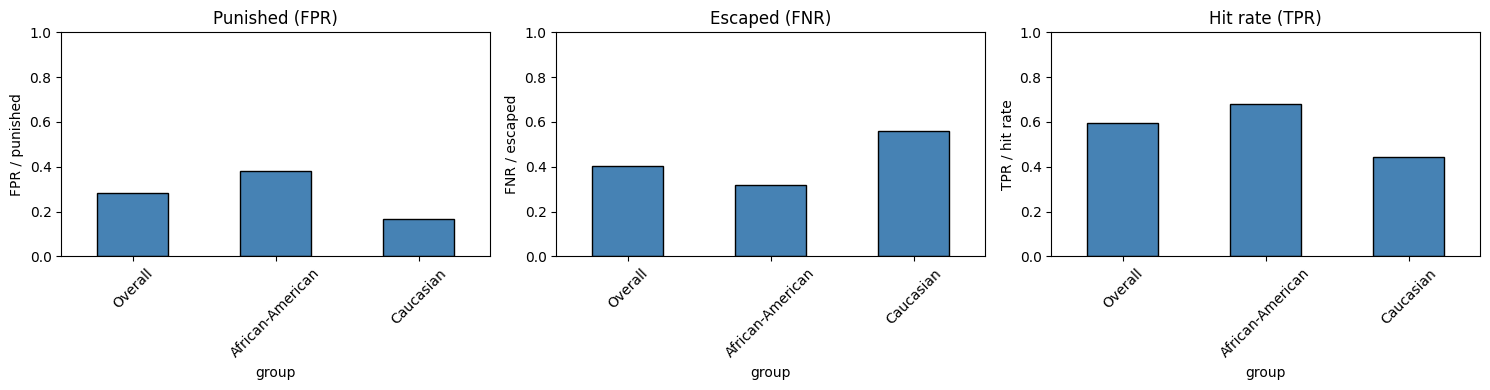

TP: correctly flagged high risk
FN: escaped (missed reoffense)
FP: punished (false alarm)
TN: correctly flagged low risk


In [3]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

audit_model = audit["model"]
y_test = audit["y_test"]
race_test = audit["race_test"]
y_score = audit["y_score"]
y_pred = audit["y_pred"]

confusion_labels = {
    "TP": "correctly flagged high risk",
    "FN": "escaped (missed reoffense)",
    "FP": "punished (false alarm)",
    "TN": "correctly flagged low risk",
}


def confusion_counts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn}


def audit_row(y_true, y_pred, group_name):
    counts = confusion_counts(y_true, y_pred)
    tn, fp, fn, tp = counts["TN"], counts["FP"], counts["FN"], counts["TP"]
    return {
        "group": group_name,
        "n": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "TPR / hit rate": tp / (tp + fn) if (tp + fn) else np.nan,
        "FPR / punished": fp / (fp + tn) if (fp + tn) else np.nan,
        "FNR / escaped": fn / (fn + tp) if (fn + tp) else np.nan,
        **counts,
    }


audit_rows = [audit_row(y_test, y_pred, "Overall")]
for group in sorted(race_test.unique()):
    mask = race_test == group
    audit_rows.append(audit_row(y_test[mask], y_pred[mask], group))

audit_table = pd.DataFrame(audit_rows)
display(audit_table)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_df = audit_table.set_index("group")
for ax, col, title in zip(
    axes,
    ["FPR / punished", "FNR / escaped", "TPR / hit rate"],
    ["Punished (FPR)", "Escaped (FNR)", "Hit rate (TPR)"],
):
    plot_df[col].plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

for label, meaning in confusion_labels.items():
    print(f"{label}: {meaning}")


### 💡 Station 2 - Reflection - What is your takeaway? 

---
#### 🟢🟢🟢 Station 3 - Final verdict - how fair is our model?

So far, we have focused on model performance and largely ignored the data itself. However, as you already know from the seminar and previous tutorial, historical and societal biases can be reflected in the data and carried over into the models trained on it.

A pragmatic argument may be that, regardless of the root cause, if one group exhibits a higher observed risk of recidivism, then a model should reflect that difference. After all, we haven't yet achieved a perfect world. 
Let's put this idea to test! 

- Check the recidivism rate for black and white populations **from the data alone**.
- Check the **predicted** recidivism rate of the model for the two populations.
- How do they compare? What do you conclude?


,group,actual recidivism rate,predicted recidivism rate,difference (predicted - actual)
0,Overall,0.466190,0.429779,-0.036411
1,African-American,0.509290,0.533333,0.024044
2,Caucasian,0.402889,0.277689,-0.125201


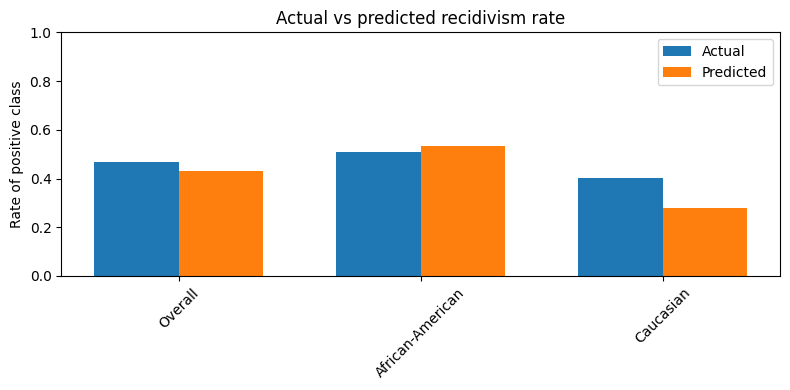

Actual recidivism gap (African-American - Caucasian): 0.106
Predicted recidivism gap (African-American - Caucasian): 0.256
The model amplifies racial differences in positive rates.


In [4]:
def recidivism_rate(values):
    return np.mean(values == 1)


comparison_rows = []
for group in ["Overall"] + sorted(race_test.unique()):
    if group == "Overall":
        actual_rate = recidivism_rate(y_test)
        predicted_rate = recidivism_rate(y_pred)
    else:
        mask = race_test == group
        actual_rate = recidivism_rate(y_test[mask])
        predicted_rate = recidivism_rate(y_pred[mask])

    comparison_rows.append(
        {
            "group": group,
            "actual recidivism rate": actual_rate,
            "predicted recidivism rate": predicted_rate,
            "difference (predicted - actual)": predicted_rate - actual_rate,
        }
    )

comparison = pd.DataFrame(comparison_rows)
display(comparison)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width / 2, comparison["actual recidivism rate"], width, label="Actual")
ax.bar(x + width / 2, comparison["predicted recidivism rate"], width, label="Predicted")
ax.set_xticks(x)
ax.set_xticklabels(comparison["group"], rotation=45)
ax.set_ylabel("Rate of positive class")
ax.set_ylim(0, 1)
ax.set_title("Actual vs predicted recidivism rate")
ax.legend()
plt.tight_layout()
plt.show()

actual_gap = (
    comparison.loc[comparison["group"] == "African-American", "actual recidivism rate"].iloc[0]
    - comparison.loc[comparison["group"] == "Caucasian", "actual recidivism rate"].iloc[0]
)
predicted_gap = (
    comparison.loc[comparison["group"] == "African-American", "predicted recidivism rate"].iloc[0]
    - comparison.loc[comparison["group"] == "Caucasian", "predicted recidivism rate"].iloc[0]
)

print(f"Actual recidivism gap (African-American - Caucasian): {actual_gap:.3f}")
print(f"Predicted recidivism gap (African-American - Caucasian): {predicted_gap:.3f}")
if abs(predicted_gap) > abs(actual_gap):
    print("The model amplifies racial differences in positive rates.")
elif abs(predicted_gap) < abs(actual_gap):
    print("The model attenuates racial differences in positive rates.")
else:
    print("The model reflects the racial differences already present in the data.")


### 💡 Station 3 - Reflection - What is your takeaway? How fair is the model? 

---
####  Can the tutor add your visualizations to the class notes? A gallery of student results helps see how different people approach the problem.

---
[Optional] 🤔💭 Was there something you struggled with? Are there any open questions?

Youe text here - 